# **student performance idecator**

## 1) Problem statment
- This project specify the performance of students in their test score base on other independent variables like Gender, Ethnicity, parantal level of education, LUnch and Preparation of Test

## 2) Data Collection
- data set is taken from kaggle
- shape of dataset is (8,1000)

## 3) dataset information
- gender: sex of students either male or female
- race: ethincity of student --> grouped in A,B,C,D and E
- parental level of education: parents final level of education, mean what is their last degree of education
- lunch : having lunch before test
- test preparation course: either complete or note before the test
- math score
- reading score
- writing score

In [1]:
# importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# import data
df = pd.read_csv('Data/students.csv')

In [3]:
#getting top 5 rows
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# columns of dataset
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [5]:
# number of column 
df.shape[1]

8

there are 8 columns in dataset

In [6]:
# number of rows in dataset
df.shape[0]

1000

1000 rows total

In [7]:
# getting more information about data use info function
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


here some column are in string data type and some are in integer data type

# **check missing values**

In [8]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

no null values, here our main aim is how to implement end to end project

In [9]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

no duplicate values in the dataset

In [10]:
# checking unique instances in each attribute
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [11]:
# checking the non numerical column
df_non_num = df.select_dtypes(include = 'str')
for column in df_non_num.columns:
    print(df[column].value_counts())
    
    print("***"*8)

gender
female    518
male      482
Name: count, dtype: int64
************************
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
************************
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
************************
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
************************
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
************************


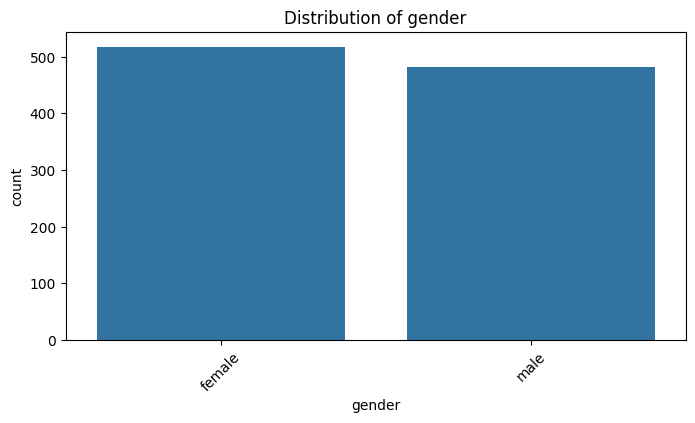

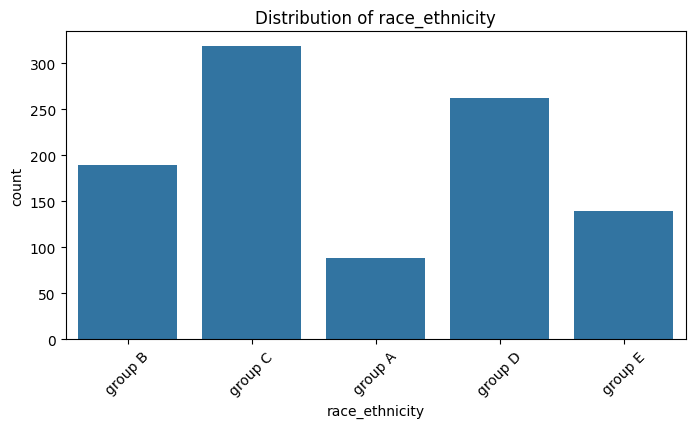

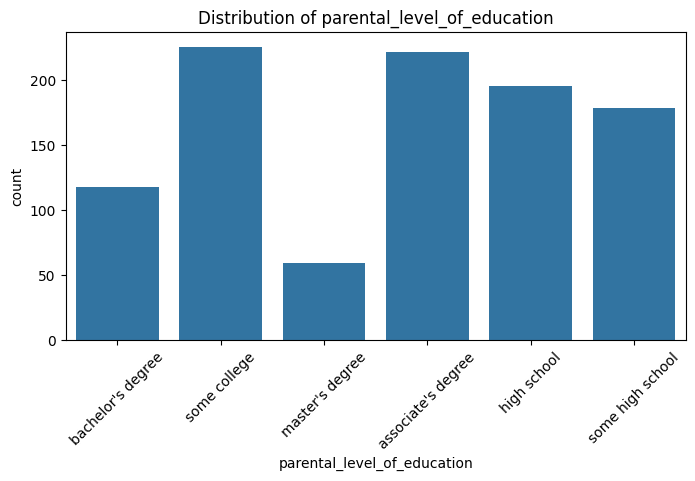

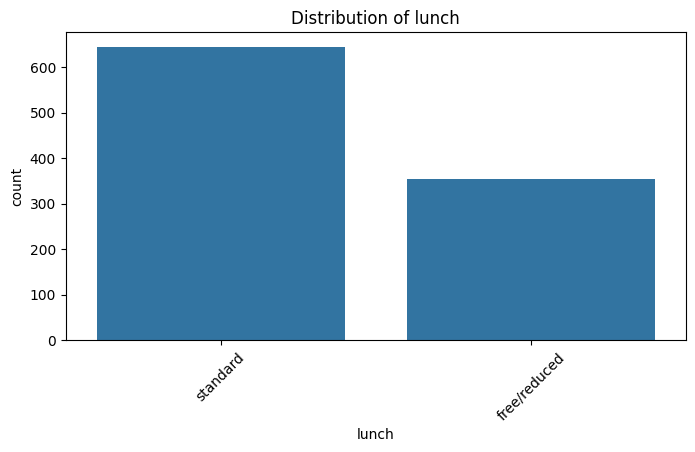

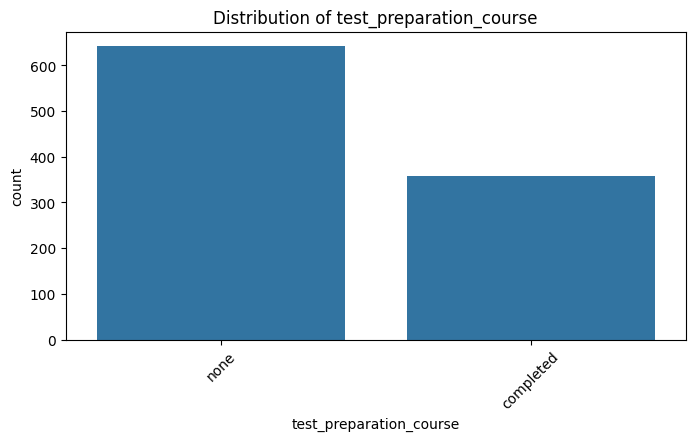

In [12]:
# plot the each category 

for column in df_non_num.columns:
    plt.figure(figsize=(8, 4)) # Sets the size for each plot
    sns.countplot(data=df, x=column)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45) # Prevents overlapping labels
    plt.show()

In [13]:
# check the statists 
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


- Performance Ranking: Students generally perform best in Reading (69.17 mean) and worst in Math (66.09 mean).
- The "Middle" Student (Median): Half of the students scored 66 or lower in Math, but 70 or lower in Reading.
- Consistency: The Standard Deviation (std) is similar across all subjects (~15 points), meaning the spread of scores is consistent.

In [14]:
# getting the numerical column 
num_column = [column for column in df.columns if df[column].dtype!='str']
num_column

['math_score', 'reading_score', 'writing_score']

in modern python object and str are treated differently, if we write 'O' it will return all

In [15]:
cat_col = [col for col in df.columns if df[col].dtype=='str']
cat_col

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

In [16]:
print(f"we have {len(num_column)} numerical columns in our dataset")
print(f"we have {len(cat_col)} numerical columns in our dataset")

we have 3 numerical columns in our dataset
we have 5 numerical columns in our dataset


In [17]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [18]:
# here we don't have total score and average score
total_score = df['math_score'] + df['reading_score'] + df['writing_score']
total_score[0]

np.int64(218)

In [19]:
# finding average score
average_score = total_score/3

In [20]:
# making column of total_score and average_score
df['total_score'] = total_score
df['averag_score'] = average_score

In [21]:
df.head(1)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,averag_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667


here we have two columns and can make 2 model to predict total score and average score

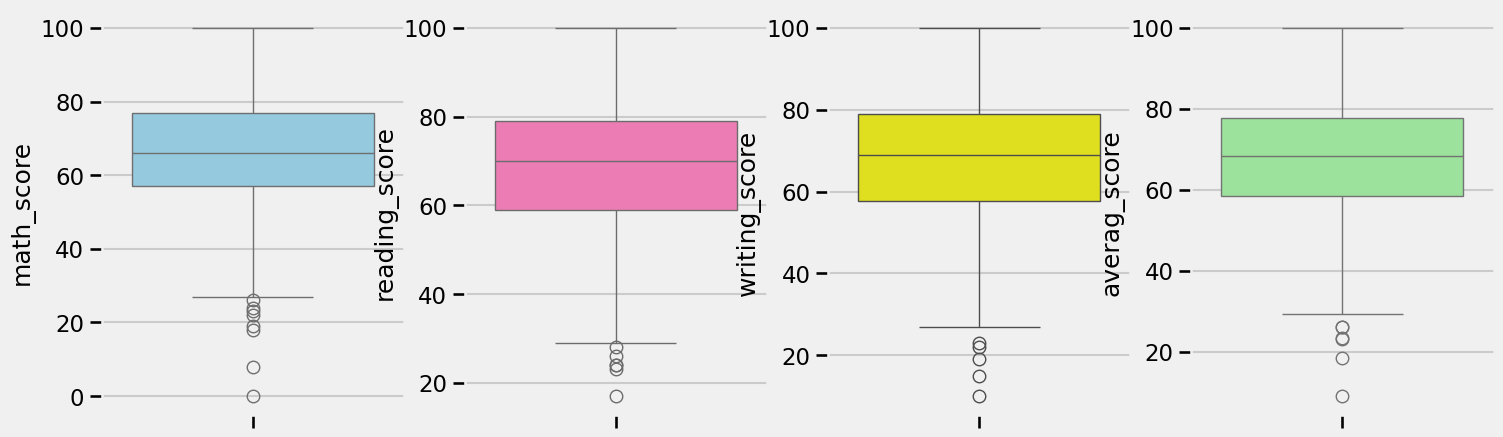

In [109]:
#outliers
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['averag_score'],color='lightgreen')
plt.show()

1. Students generally score highest in reading, followed closely by writing, and lowest in math.
2. Median Scores: The middle lines show that the average student scores around 70 in reading, 69 in writing, and 66 in math.
3. Core Spread (IQR): The middle 50% of students (the colored boxes) perform remarkably similarly across all subjects, generally spanning from the high 50s to the high 70s.
4. Low Performers (Outliers): The individual circles at the bottom highlight severe low outliers. Math has the worst single failing score, dropping all the way to 0 points.
5. No Perfect Outliers: The upper whiskers stretch all the way up to 100, meaning top students achieved perfect scores, but these are not considered outliers.

In [22]:
# checking number of student getting full marks in each 
full_reading = df[df['reading_score']==100]['averag_score'].count()
full_wrinting = df[df['writing_score']==100]['averag_score'].count()
full_math = df[df['math_score']==100]['averag_score'].count()
print(f"number of students who get full marks in reading are {full_reading}")
print(f"number of students who get full marks in writing are {full_wrinting}")
print(f"number of students who get full marks in math are {full_math}")

number of students who get full marks in reading are 17
number of students who get full marks in writing are 14
number of students who get full marks in math are 7


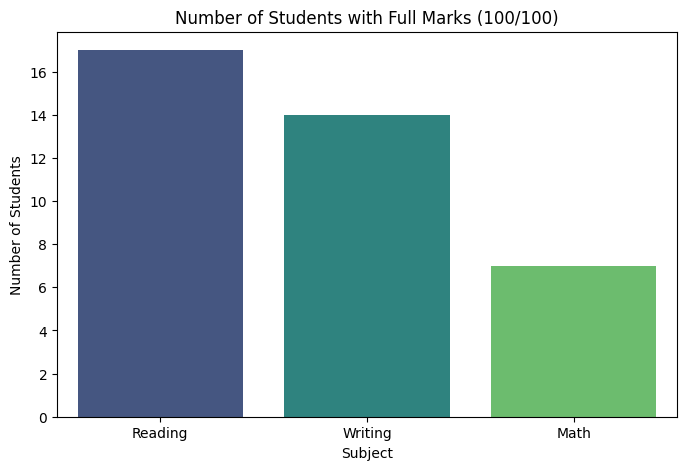

In [23]:
#visualize the result 
# 1. Create a dictionary of results
data = {
    'Subject': ['Reading', 'Writing', 'Math'],
    'Full Marks Count': [full_reading, full_wrinting, full_math]
}

# 2. Convert to a DataFrame
df_full_marks = pd.DataFrame(data)

# 3. Plot using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=df_full_marks, x='Subject', y='Full Marks Count', palette='viridis')

# Add labels and title
plt.title('Number of Students with Full Marks (100/100)')
plt.ylabel('Number of Students')
plt.show()

In [24]:
#number of student in each who get less than 40 marks in each 
reading_40 = df[df['reading_score']<40]['averag_score'].count()
wrinting_40 = df[df['writing_score']<40]['averag_score'].count()
math_40 = df[df['math_score']<40]['averag_score'].count()
print(f"number of students who get full marks in reading are {reading_40}")
print(f"number of students who get full marks in writing are {wrinting_40}")
print(f"number of students who get full marks in math are {math_40}")

number of students who get full marks in reading are 26
number of students who get full marks in writing are 32
number of students who get full marks in math are 40


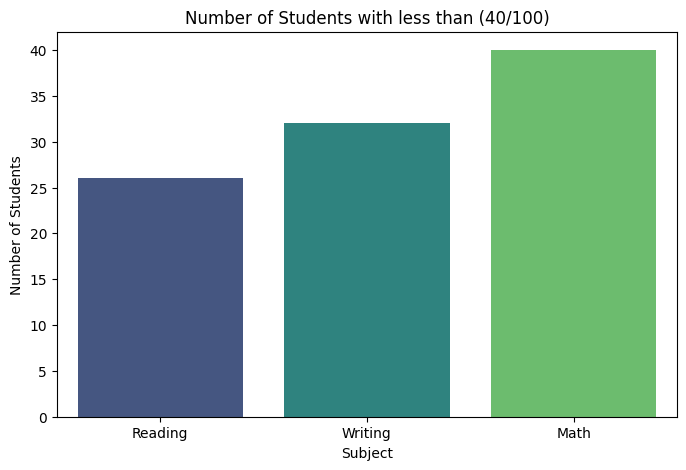

In [25]:
#visualize the result 

data = {
    'Subject': ['Reading', 'Writing', 'Math'],
    'Full Marks Count': [reading_40, wrinting_40, math_40]
}

# 2. Convert to a DataFrame
df_full_marks = pd.DataFrame(data)

# 3. Plot using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=df_full_marks, x='Subject', y='Full Marks Count', palette='viridis')

# Add labels and title
plt.title('Number of Students with less than (40/100)')
plt.ylabel('Number of Students')
plt.show()

## worst performance is in Math and good performance is in Reading

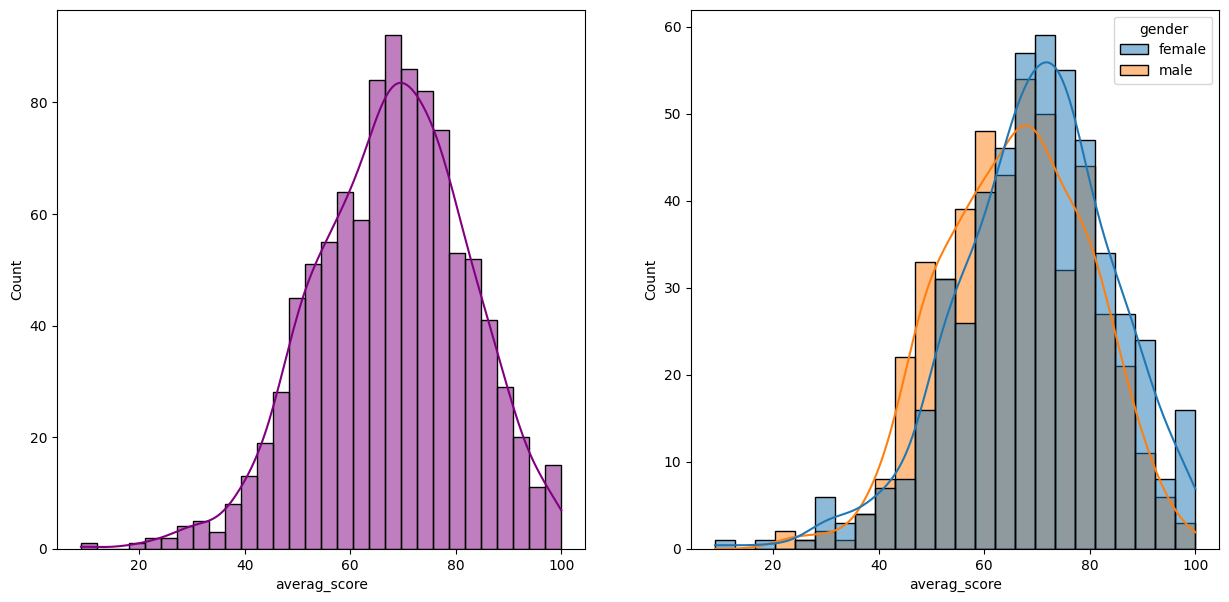

In [26]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='averag_score',bins=30,kde=True,color='purple')
plt.subplot(122)
sns.histplot(data=df,x='averag_score',kde=True,hue='gender')
plt.show()

## **female has more good average score as compare to male**

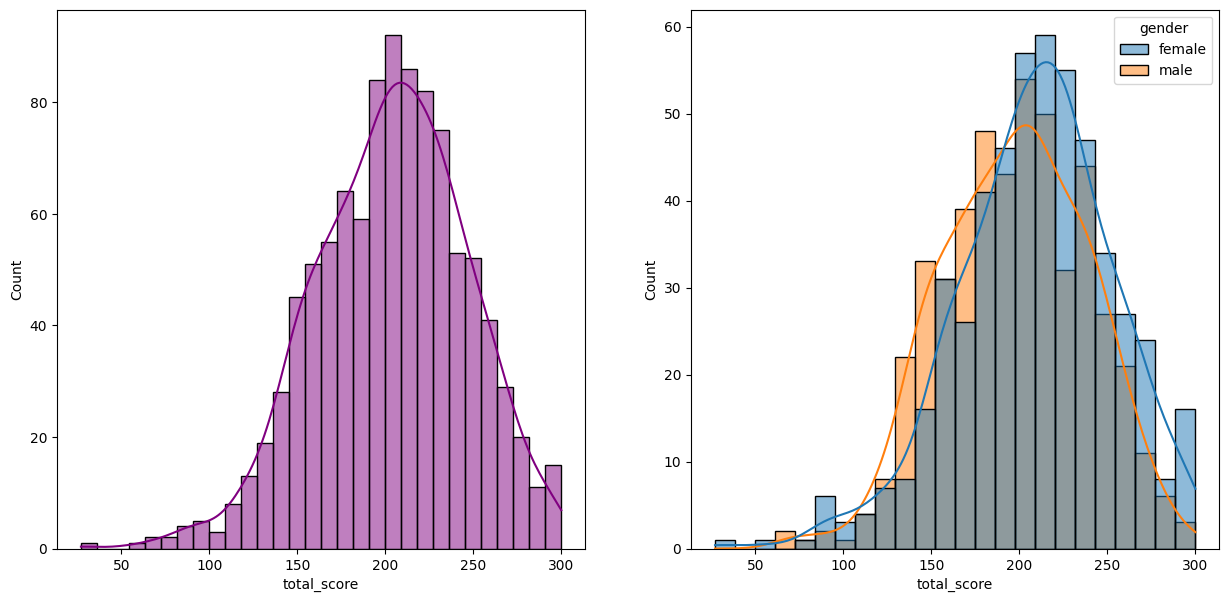

In [27]:
# check performance w.r.t gender in total score
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='purple')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

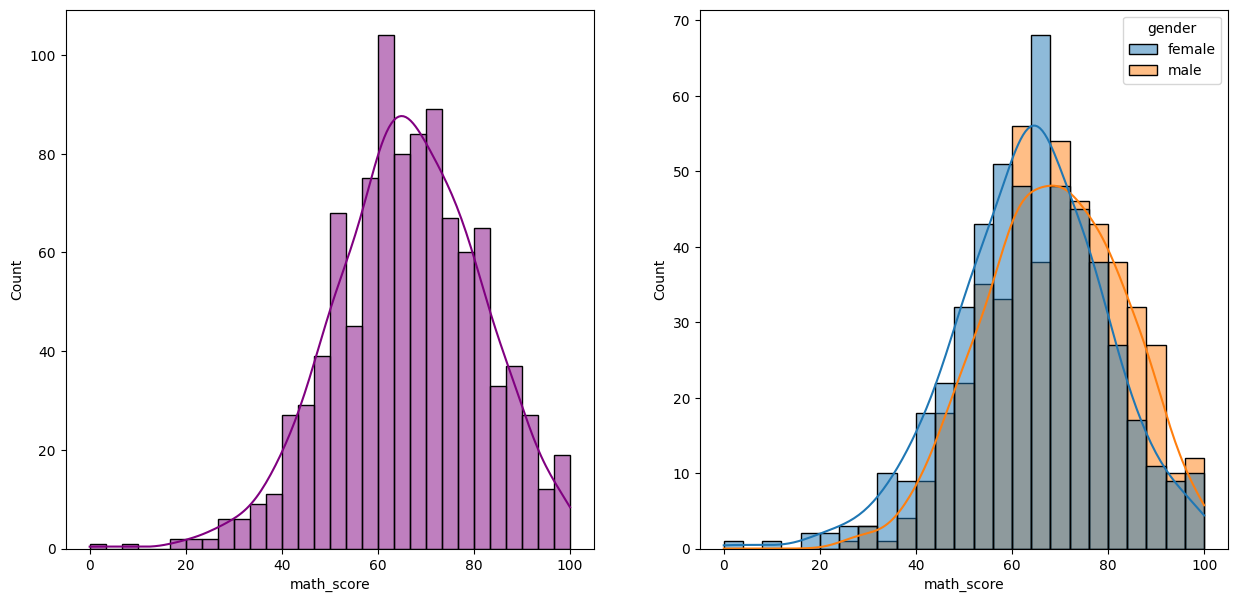

In [28]:
# checking in math, let see usually male are more intelligent than female in math
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='math_score',bins=30,kde=True,color='purple')
plt.subplot(122)
sns.histplot(data=df,x='math_score',kde=True,hue='gender')
plt.show()


hence it is shown male are higher scorer in math than female

In [53]:
df[(df['gender'] == 'female') & (df['total_score'] == 300)]


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,averag_score
458,female,group E,bachelor's degree,standard,none,100,100,100,300,100.0
962,female,group E,associate's degree,standard,none,100,100,100,300,100.0


In [54]:
df[(df['gender'] == 'male') & (df['total_score'] == 300)]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,averag_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,100.0


there are 2 female and 1 male who score 300

In [55]:
#number of male and female in data 
df.gender.value_counts()

gender
female    518
male      482
Name: count, dtype: int64

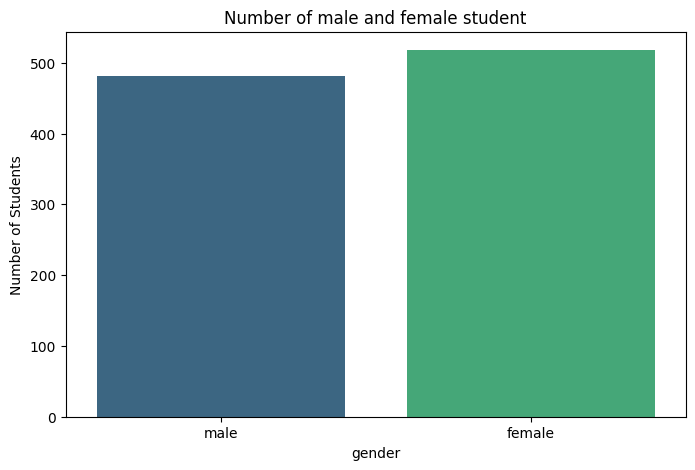

In [59]:
#visualize 

data = {
    'gender': ['male', 'female'],
    'frequency': [482, 518]
}

# 2. Convert to a DataFrame
df_gender_frequency = pd.DataFrame(data)

# 3. Plot using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=df_gender_frequency, x='gender', y='frequency', palette='viridis')

# Add labels and title
plt.title('Number of male and female student')
plt.ylabel('Number of Students')
plt.show()

**number of male students are 482 and female are 518**

In [60]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'averag_score'],
      dtype='str')

In [63]:
df.groupby('gender').value_counts()

gender  race_ethnicity  parental_level_of_education  lunch         test_preparation_course  math_score  reading_score  writing_score  total_score  averag_score
female  group B         bachelor's degree            standard      none                     72          72             74             218          72.666667       1
        group D         some college                 free/reduced  completed                63          80             80             223          74.333333       1
        group E         bachelor's degree            free/reduced  completed                92          100            100            292          97.333333       1
        group D         master's degree              free/reduced  completed                61          71             78             210          70.000000       1
        group C         some college                 standard      none                     53          62             56             171          57.000000       1
               

In [74]:
gender_parental_education = df[(df['gender']=='female') & (df['parental_level_of_education'])]
female_parent_bachlor = gender_parental_education[gender_parental_education['parental_level_of_education']=="bachelor's degree"]['total_score'].sort_values( ascending=False).head(5)
female_parent_bachlor

458    300
114    299
165    296
903    293
566    292
Name: total_score, dtype: int64

top by student who parent education level is graduation and therir total score out of 300

In [76]:
gender_parental_education = df[(df['gender']=='male') & (df['parental_level_of_education'])]
female_parent_bachlor = gender_parental_education[gender_parental_education['parental_level_of_education']=="bachelor's degree"]['total_score'].sort_values( ascending=False).head(5)
female_parent_bachlor

916    300
571    279
562    278
612    275
551    265
Name: total_score, dtype: int64

top 5 students average are better than male top five

# **more insights**

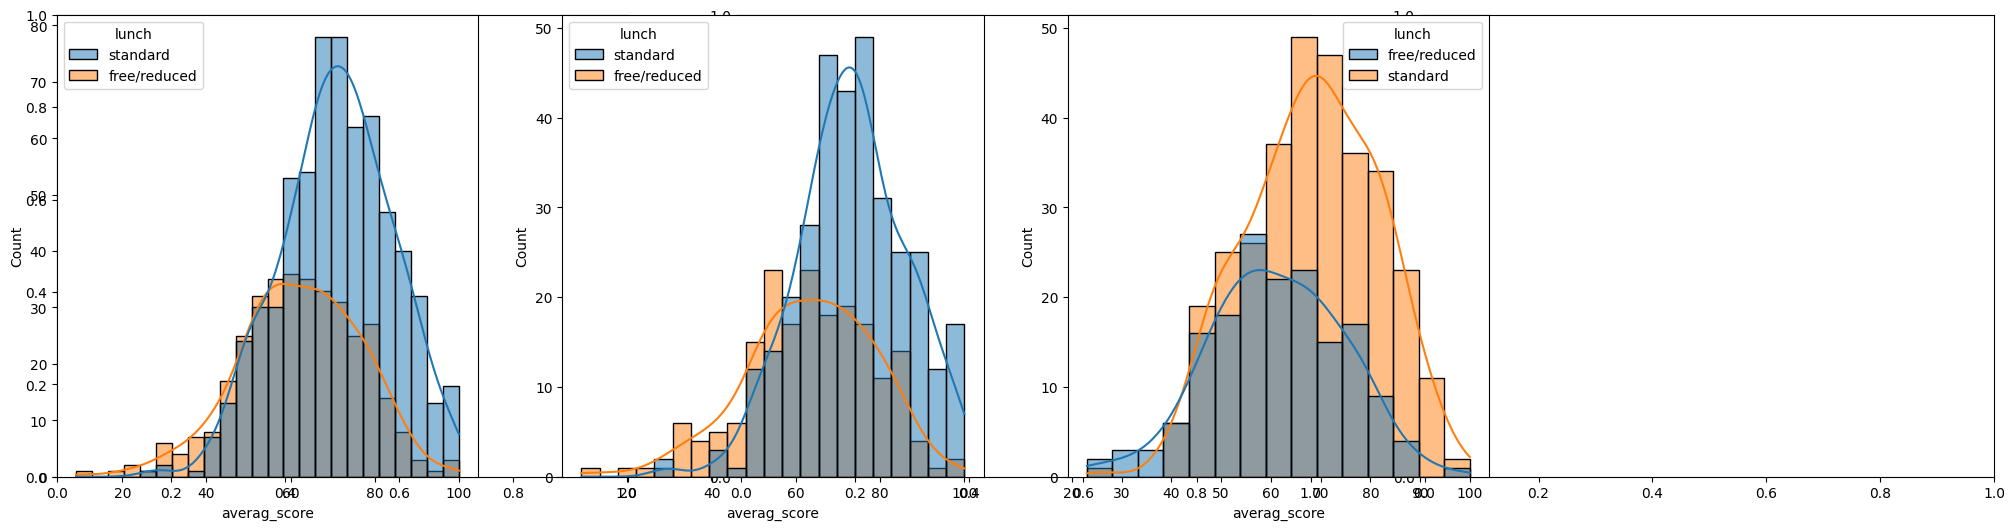

In [80]:
#insights
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='averag_score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='averag_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='averag_score',kde=True,hue='lunch')
plt.show()

 Data Interpretation
Standard Lunch (Higher Performance):
1. The curves (blue in the first two plots, orange in the third) are consistently shifted to the right.
2. Most of these students score in the 70 to 80 range.
3. The peaks are much higher, showing a large concentration of students performing well.

Free/Reduced Lunch (Lower Performance):
1. The curves are shifted to the left.
2. The scores peak lower down, mostly in the 50 to 60 range.
3. The distributions are flatter and more spread out toward lower scores (down to 20 or lower).

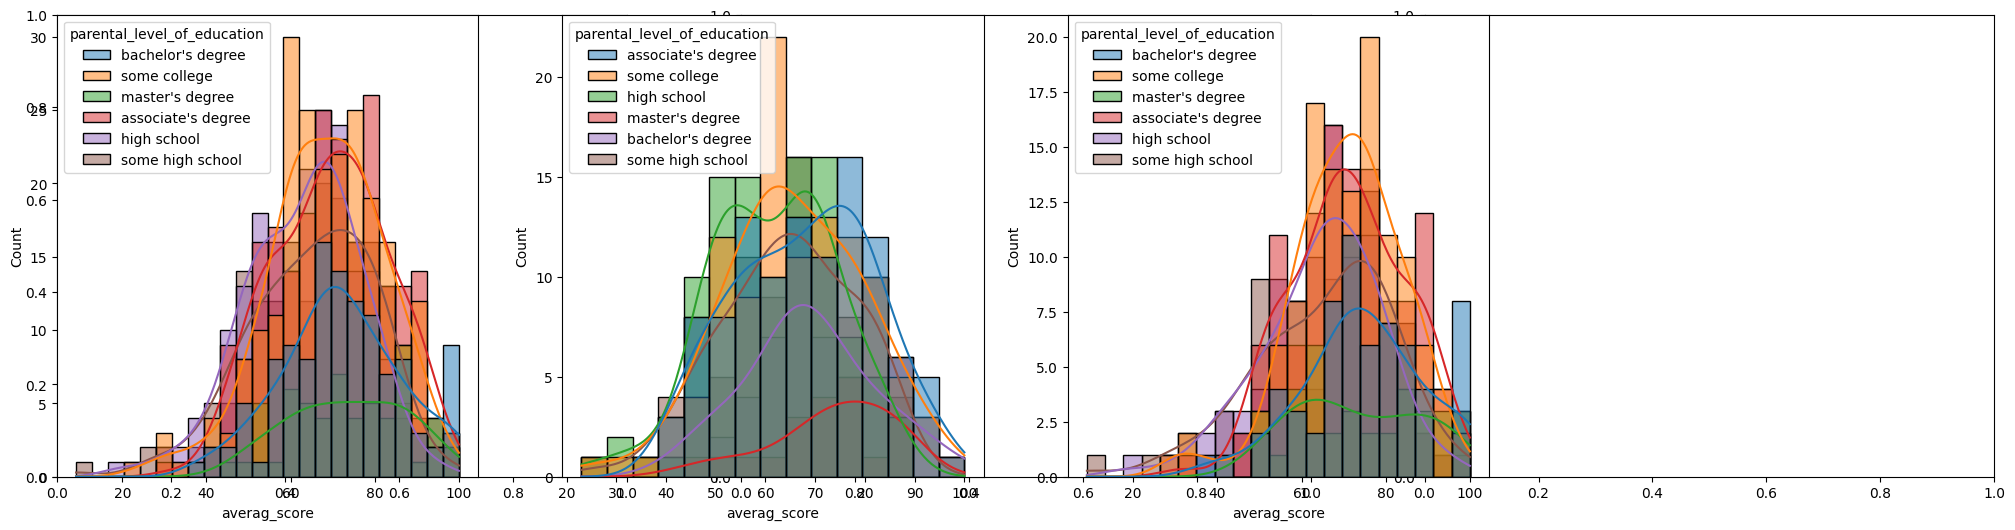

In [82]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='averag_score',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='averag_score',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='averag_score',kde=True,hue='parental_level_of_education')
plt.show()

High-Scoring
1. Master's and Bachelor's Degrees: The curves representing students with parents holding advanced degrees (such as Master's and Bachelor's) peak further to the right. A notable portion of these distributions reaches toward the maximum 80 to 100 score range.
2. Associate's and Some College: These groups form a strong middle-to-high block. They have high concentrations of students peaking tightly around the 70 to 80 score mark.

Low-Scoring 
1. High School and Some High School: The curves for students whose parents have a high school education or less are broader and notably shifted to the left.
2. Tail Distribution: While these students still achieve average scores, their groups account for the vast majority of the lower scores dipping down into the 20 to 50 range.

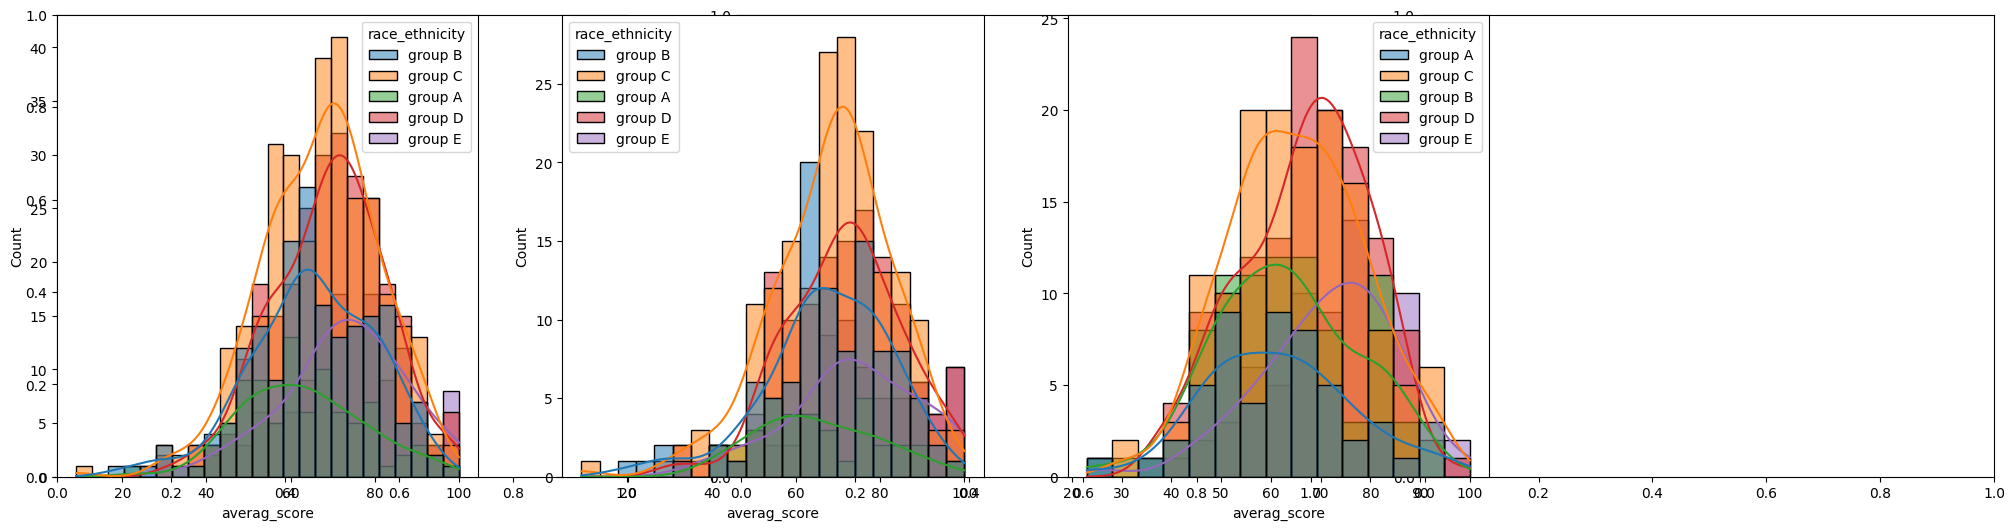

In [84]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='averag_score',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='averag_score',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='averag_score',kde=True,hue='race_ethnicity')
plt.show()

- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

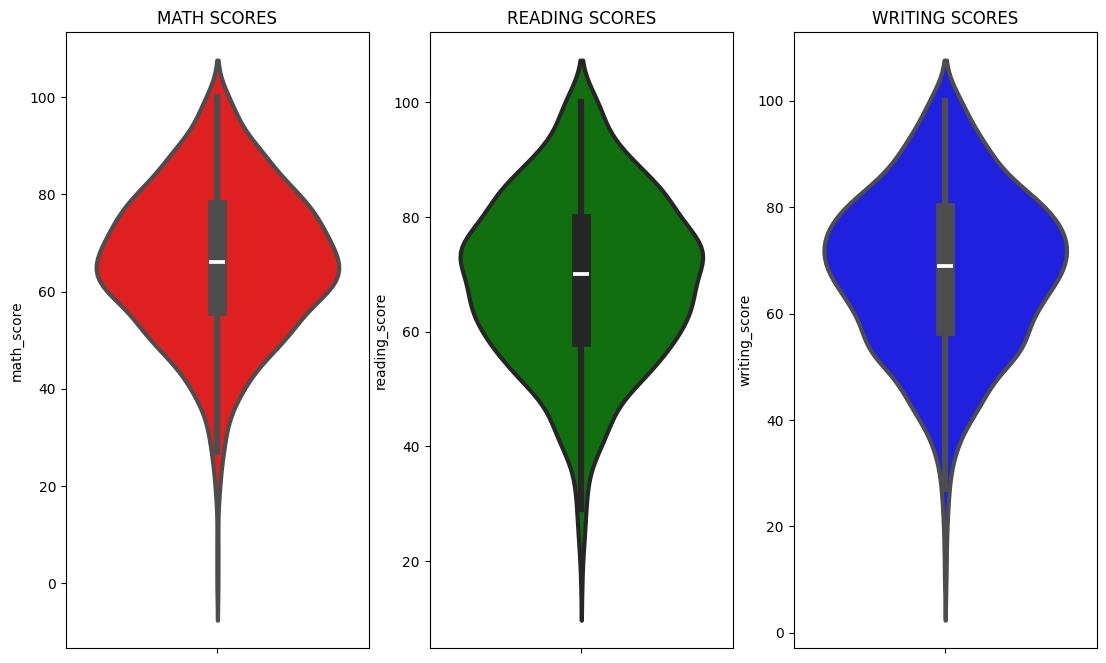

In [86]:
# maximum score of student in all 3 subject
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

In [85]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'averag_score'],
      dtype='str')

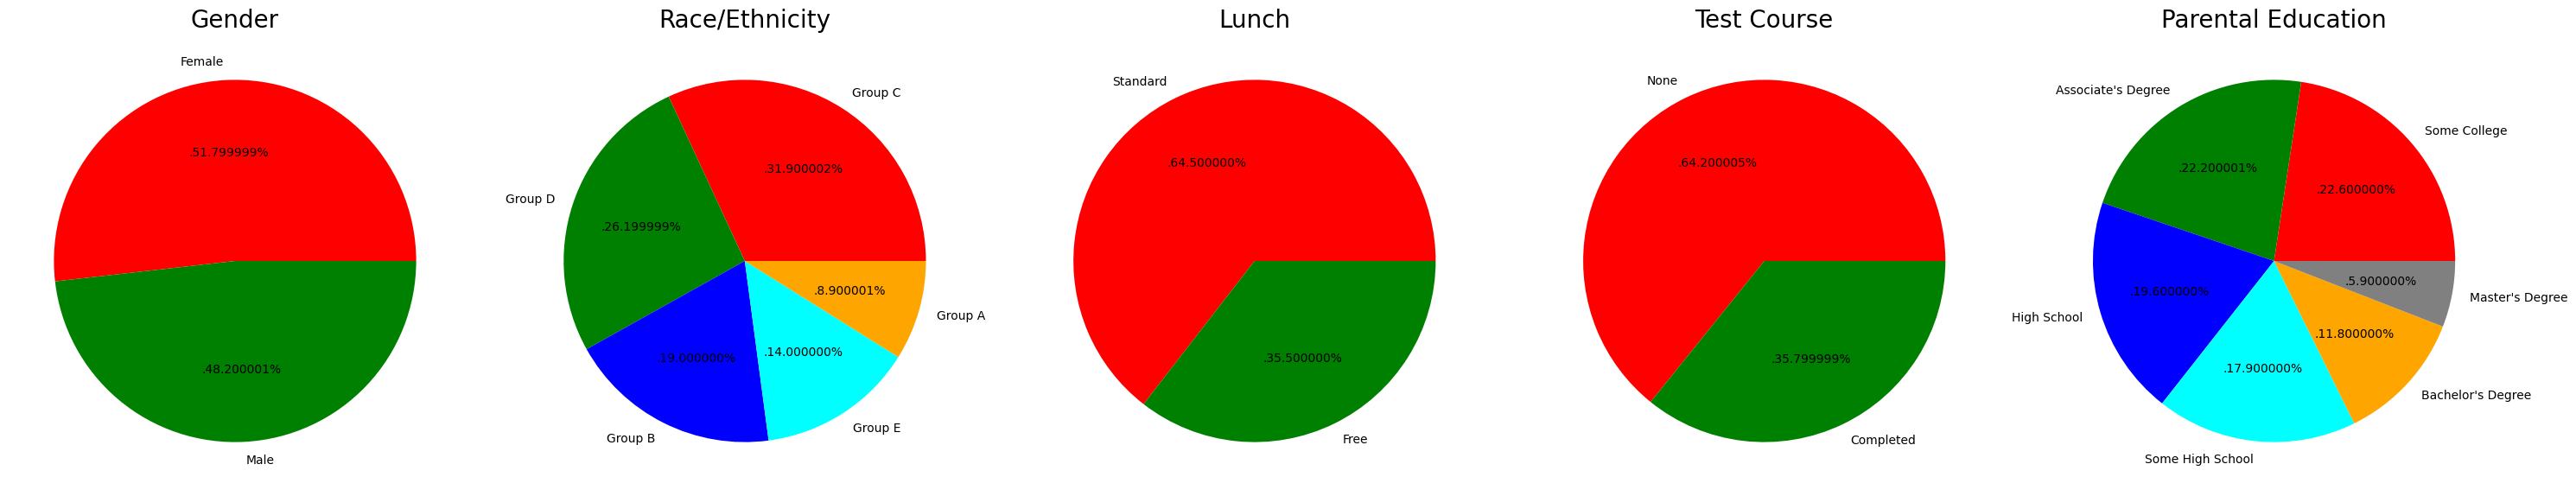

In [88]:
# multivarant analysis using pie plot
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

- These pie charts illustrate the demographic distribution of the student dataset across gender, race/ethnicity, lunch type, test preparation course completion, and parental level of education.
-  Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

# **features insights**

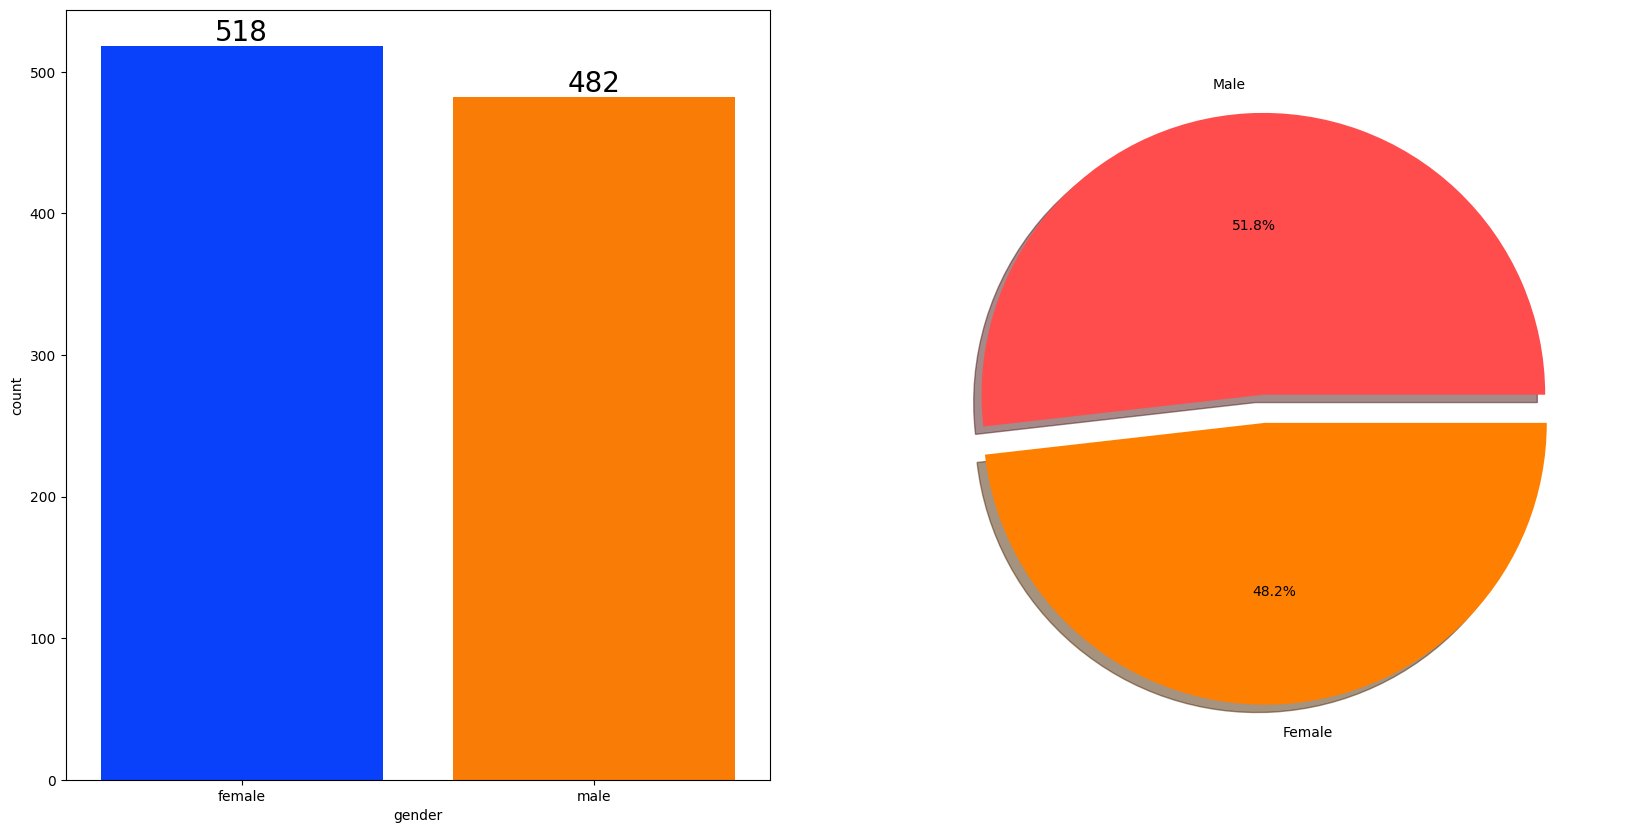

In [89]:
# 1. Gender
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [90]:
# analysis on study performance by gender basis
gender_group = df.groupby('gender').mean()
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

TypeError: dtype 'str' does not support operation 'mean'

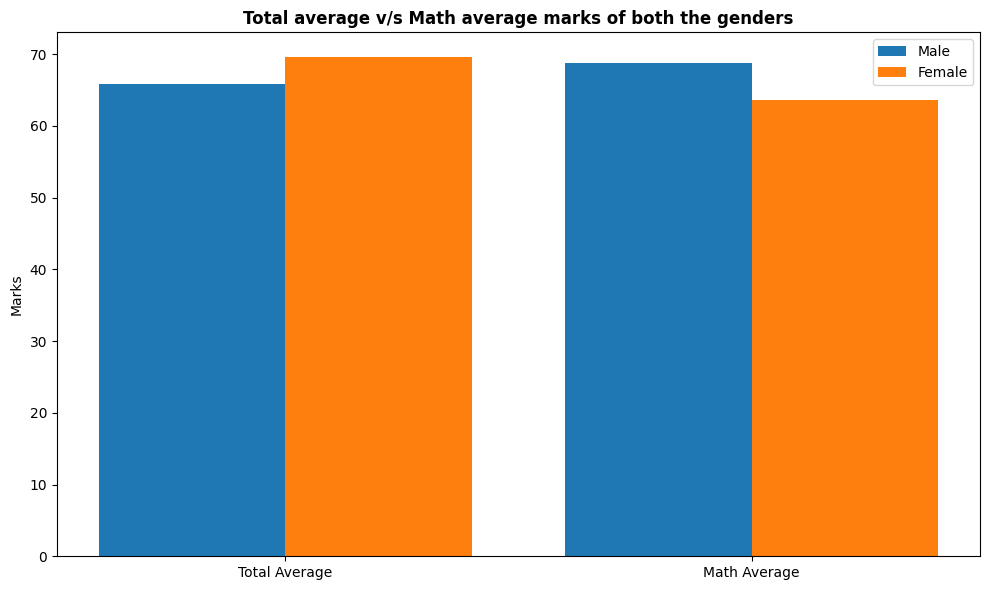

In [92]:


# 1. Add numeric_only=True to prevent pandas errors
gender_group = df.groupby("gender").mean(numeric_only=True)

X = ["Total Average", "Math Average"]

# 2. Select explicitly by index name ('male' / 'female') instead of [0] and [1]
# Note: Ensure 'average_score' matches your exact column name
female_scores = [
    gender_group.loc["female", "averag_score"],
    gender_group.loc["female", "math_score"],
]
male_scores = [
    gender_group.loc["male", "averag_score"],
    gender_group.loc["male", "math_score"],
]

X_axis = np.arange(len(X))

plt.figure(figsize=(10, 6))  # Reduced height slightly for better proportions

# 3. Plotted side-by-side grouped bars
plt.bar(X_axis - 0.2, male_scores, 0.4, label="Male", color="#1f77b4")
plt.bar(X_axis + 0.2, female_scores, 0.4, label="Female", color="#ff7f0e")

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title(
    "Total average v/s Math average marks of both the genders",
    fontweight="bold",
)
plt.legend()
plt.tight_layout()  # Prevents clipping
plt.show()


1. on average female score better than male
2. male are better scoorer in math than female

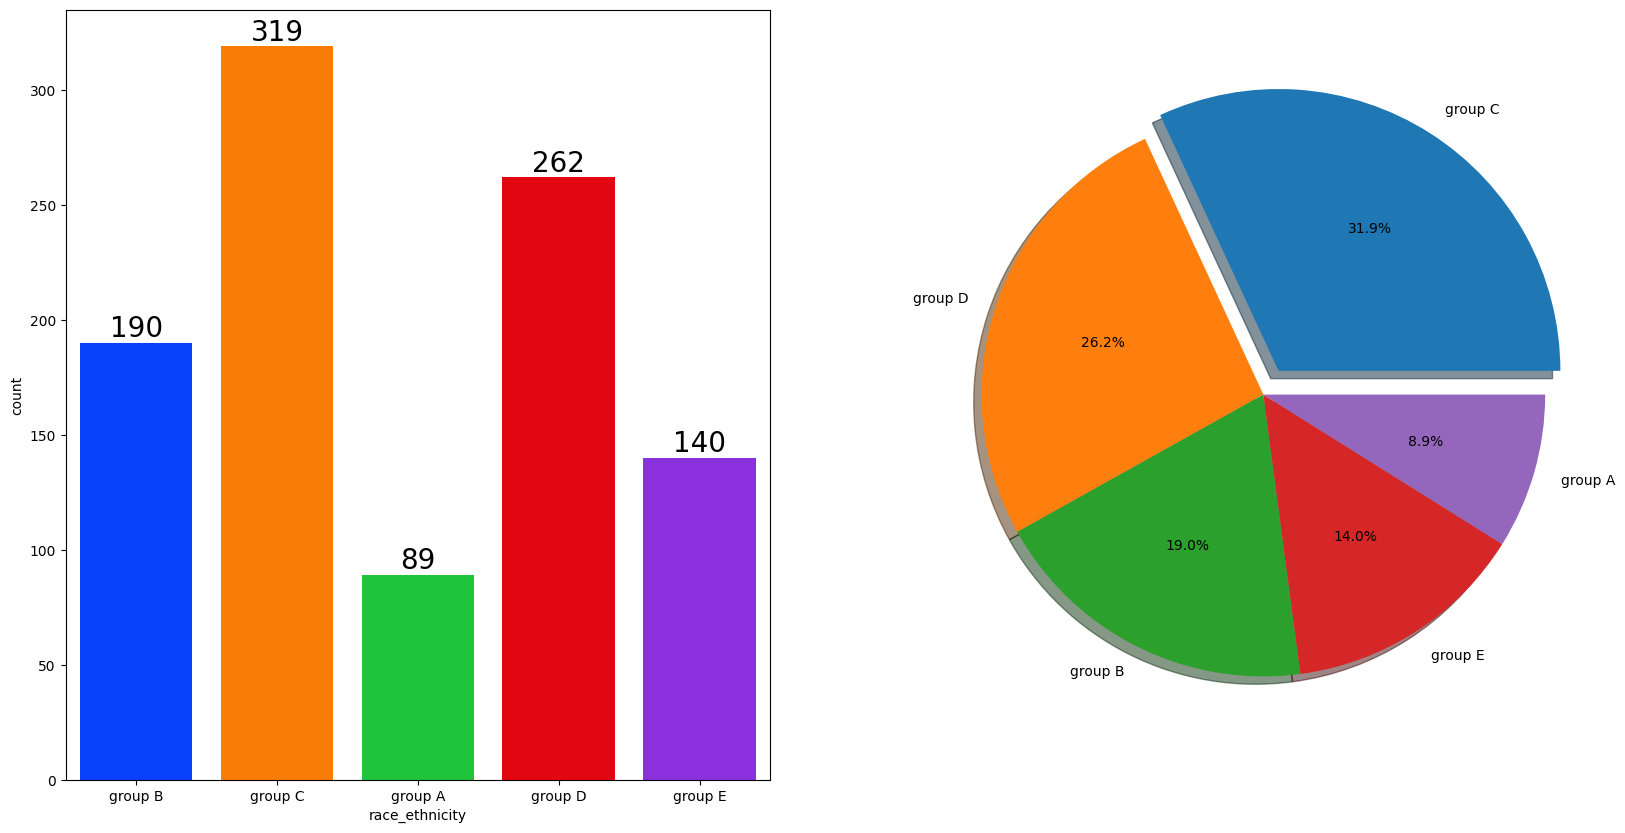

In [95]:
#univarient analysis of race_ethancity
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show() 

1. group D and c provides more students
2. lower number students come from group A

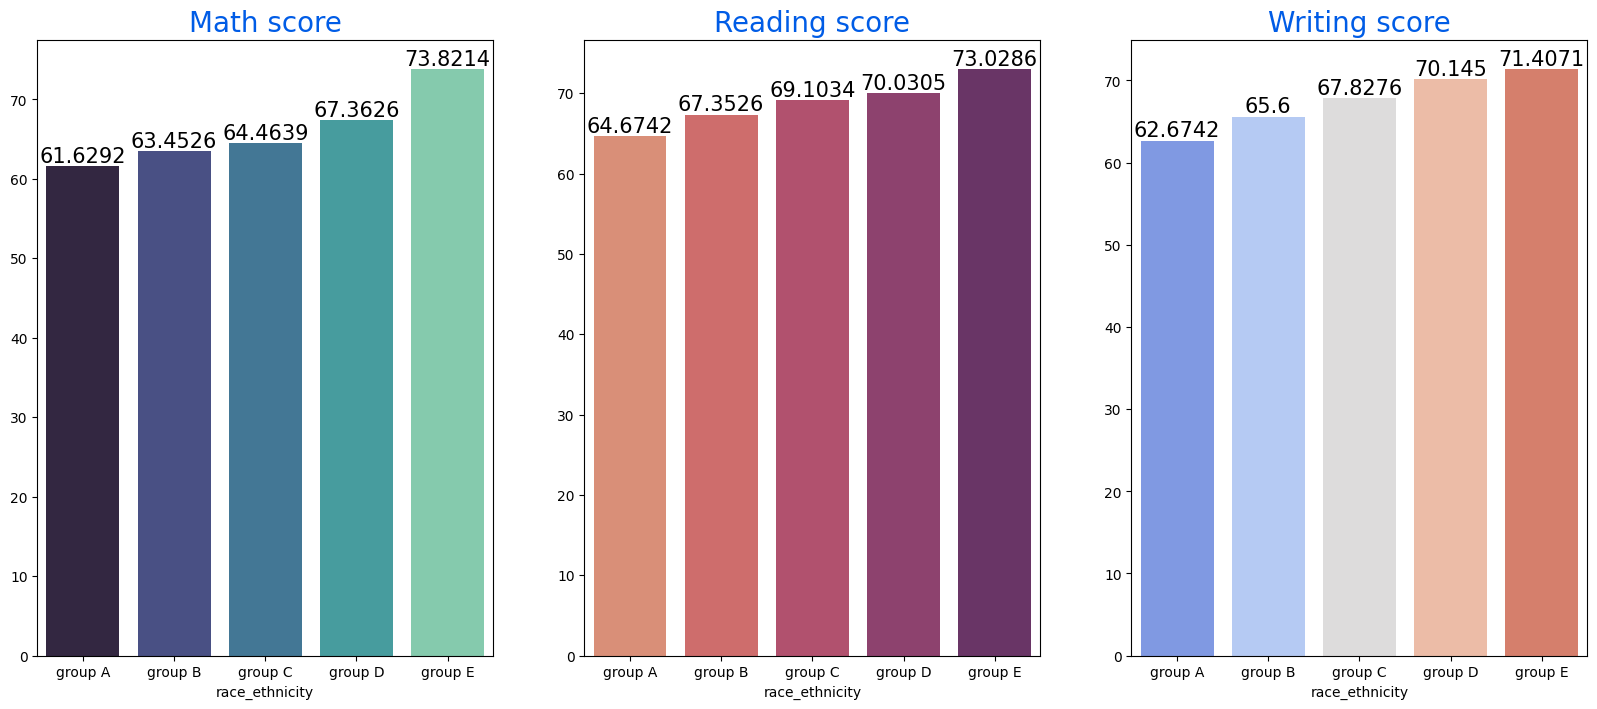

In [97]:
# race impact on study 
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

Group A score lowest in all
- group E score the highest in all 

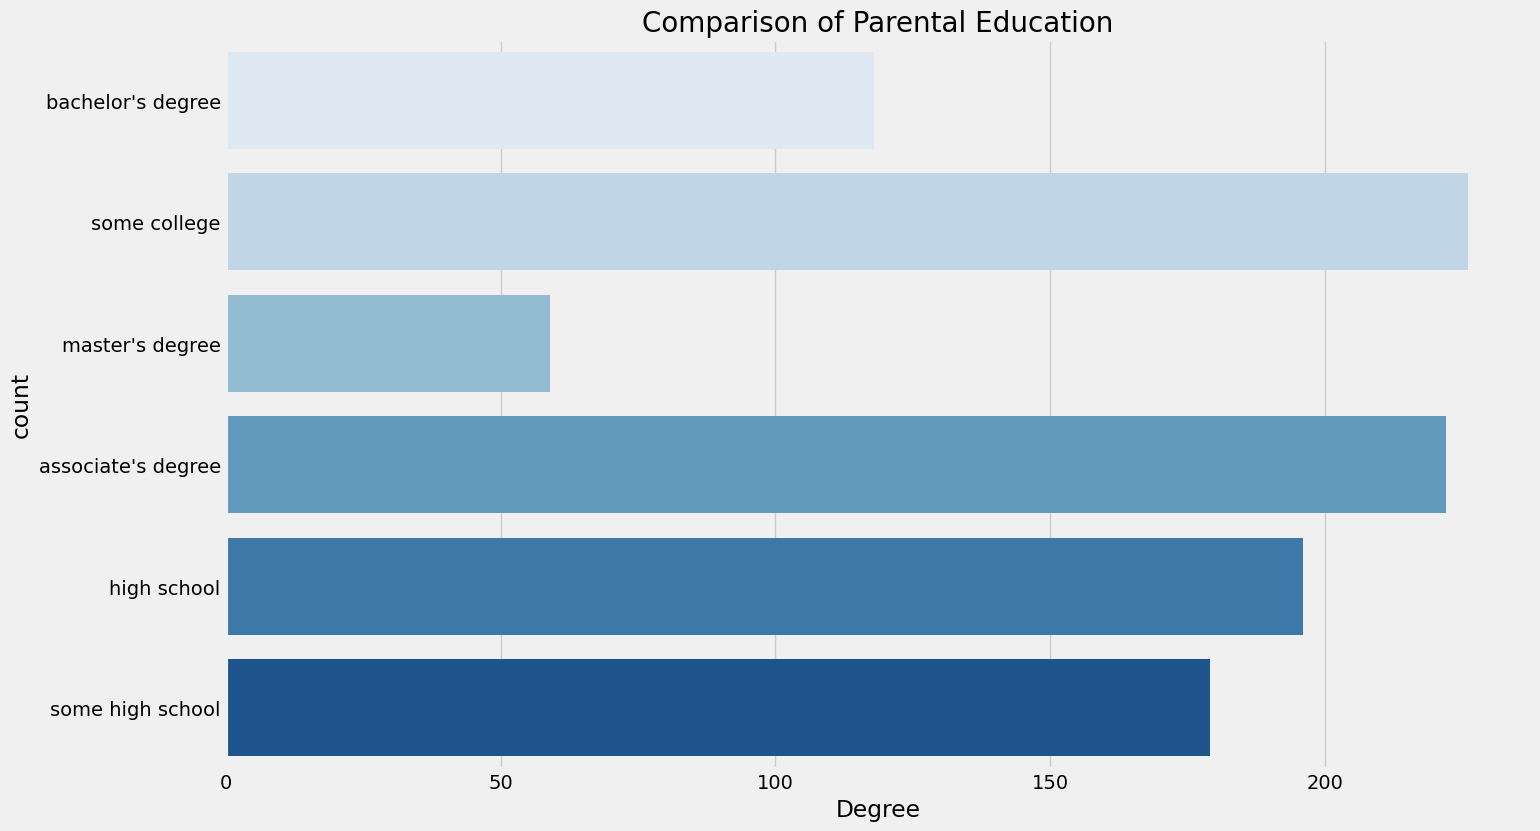

In [99]:
#univarient analysis on parental education
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

more parents of students are from college

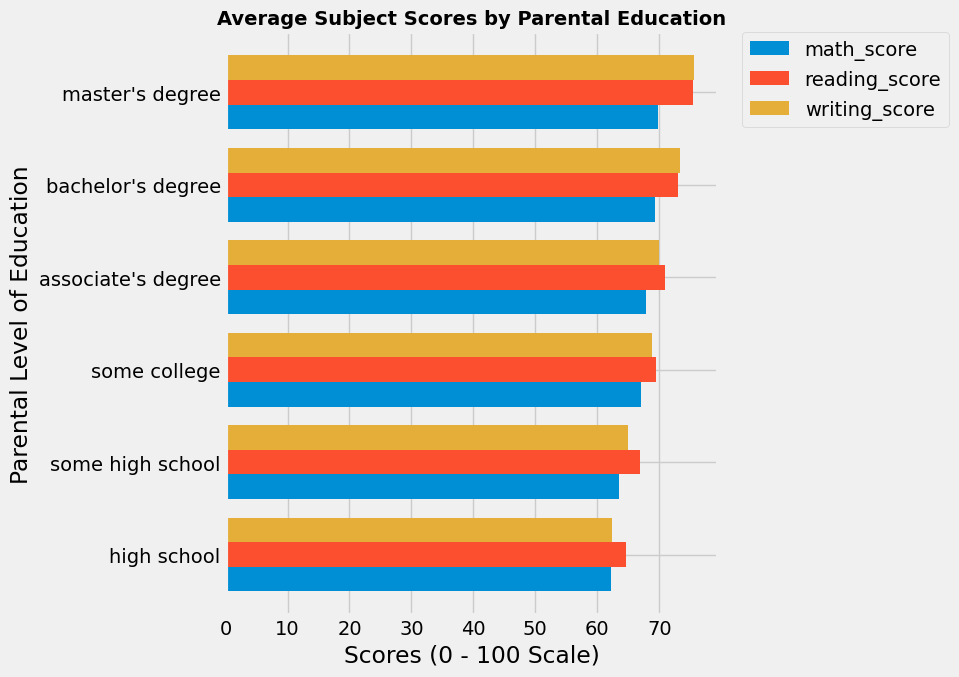

In [103]:


# 1. Calculate the mean cleanly
education_group = df.groupby("parental_level_of_education").mean(
    numeric_only=True
)


plot_data = education_group.drop(
    columns=["total_score", "averag_score"], errors="ignore"
)

# 3. Sort logically from lowest score to highest score to make trends clear
plot_data = plot_data.sort_values(by="math_score")


plot_data.plot(kind="barh", figsize=(10, 7), width=0.8)


plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.title(
    "Average Subject Scores by Parental Education",
    fontweight="bold",
    fontsize=14,
)
plt.xlabel("Scores (0 - 100 Scale)")
plt.ylabel("Parental Level of Education")
plt.tight_layout()

plt.show()


The Education Advantage: There is a clear step-by-step upward trend. As the parental education level increases, student performance across all three subjects increases systematically.

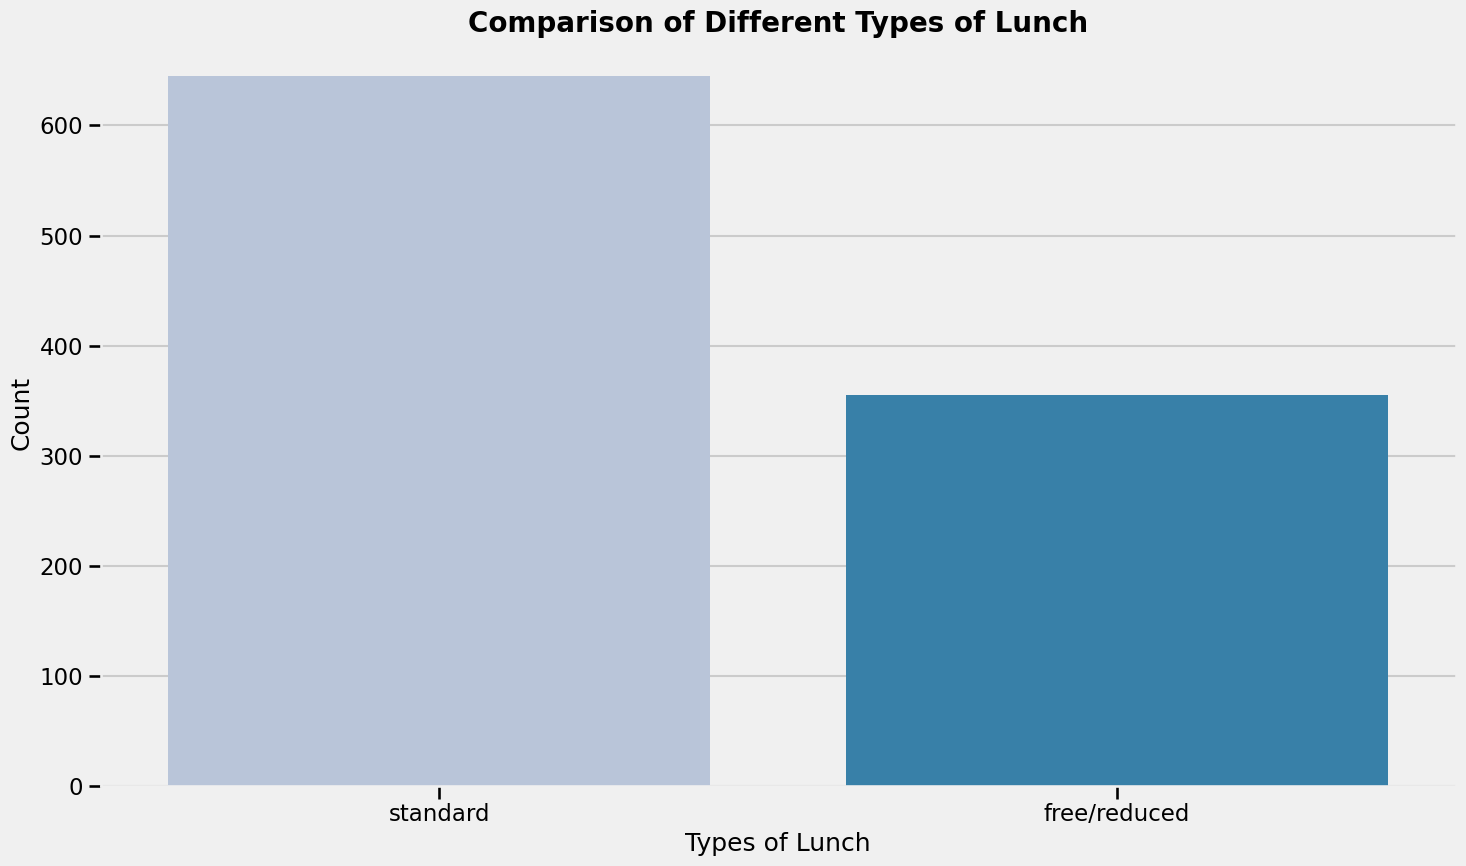

In [105]:
#uni and bivarient anlysis of lunch
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fix the figure size and apply the modern seaborn talk context
plt.rcParams["figure.figsize"] = (15, 9)
sns.set_context("talk")  # This replaces plt.style.use('seaborn-talk')

# 2. Plot using standard Seaborn syntax
# Added 'hue' to clear mapping warning in newer Seaborn versions
sns.countplot(data=df, x="lunch", palette="PuBu", hue="lunch", legend=False)

# 3. Titles and Labels
plt.title(
    "Comparison of Different Types of Lunch", fontweight="bold", fontsize=20
)
plt.xlabel("Types of Lunch")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


standard lunch's stundents are more than free lunch

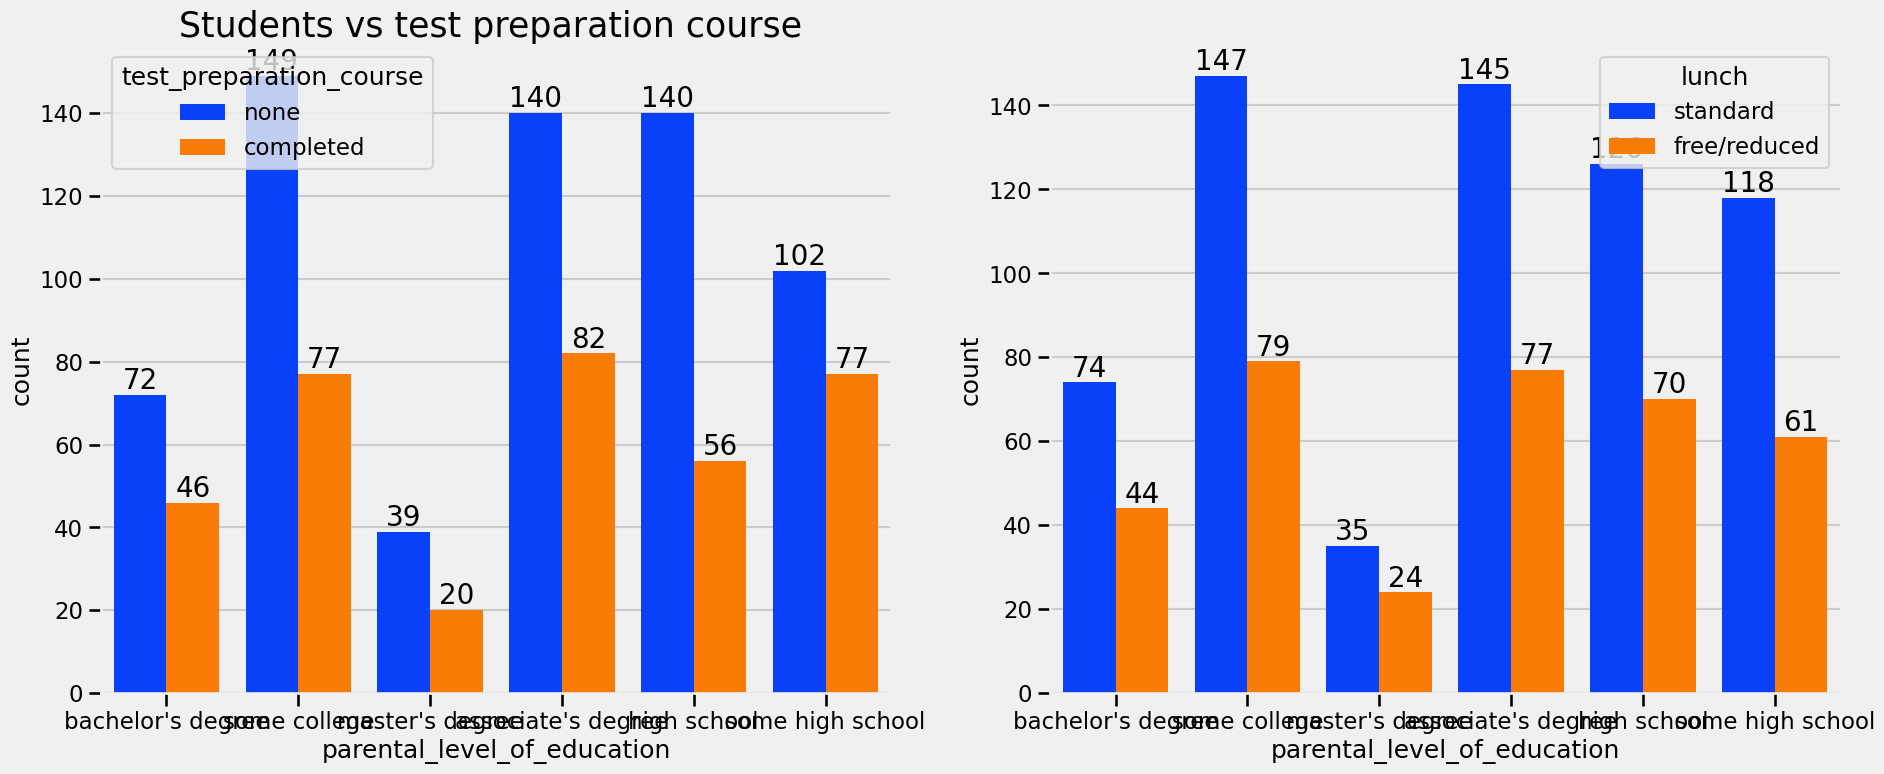

In [107]:
#lunch has impact on stundent performance or not 
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 

students perform well who get standard lunch

<Axes: xlabel='lunch', ylabel='writing_score'>

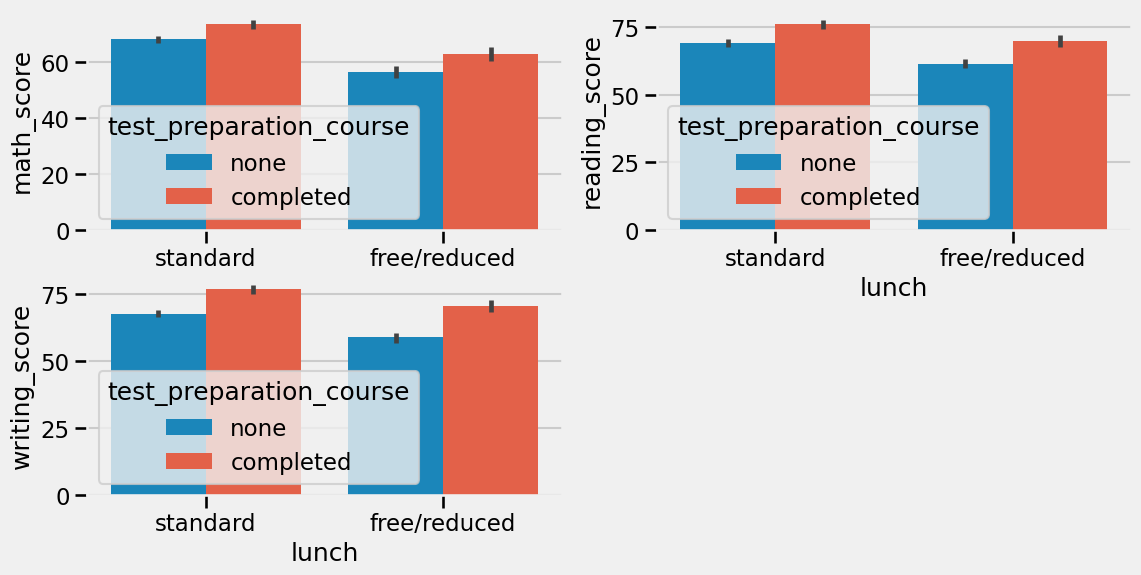

In [108]:
#test preperation and score
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

completed test preperation students score high with standard lunch

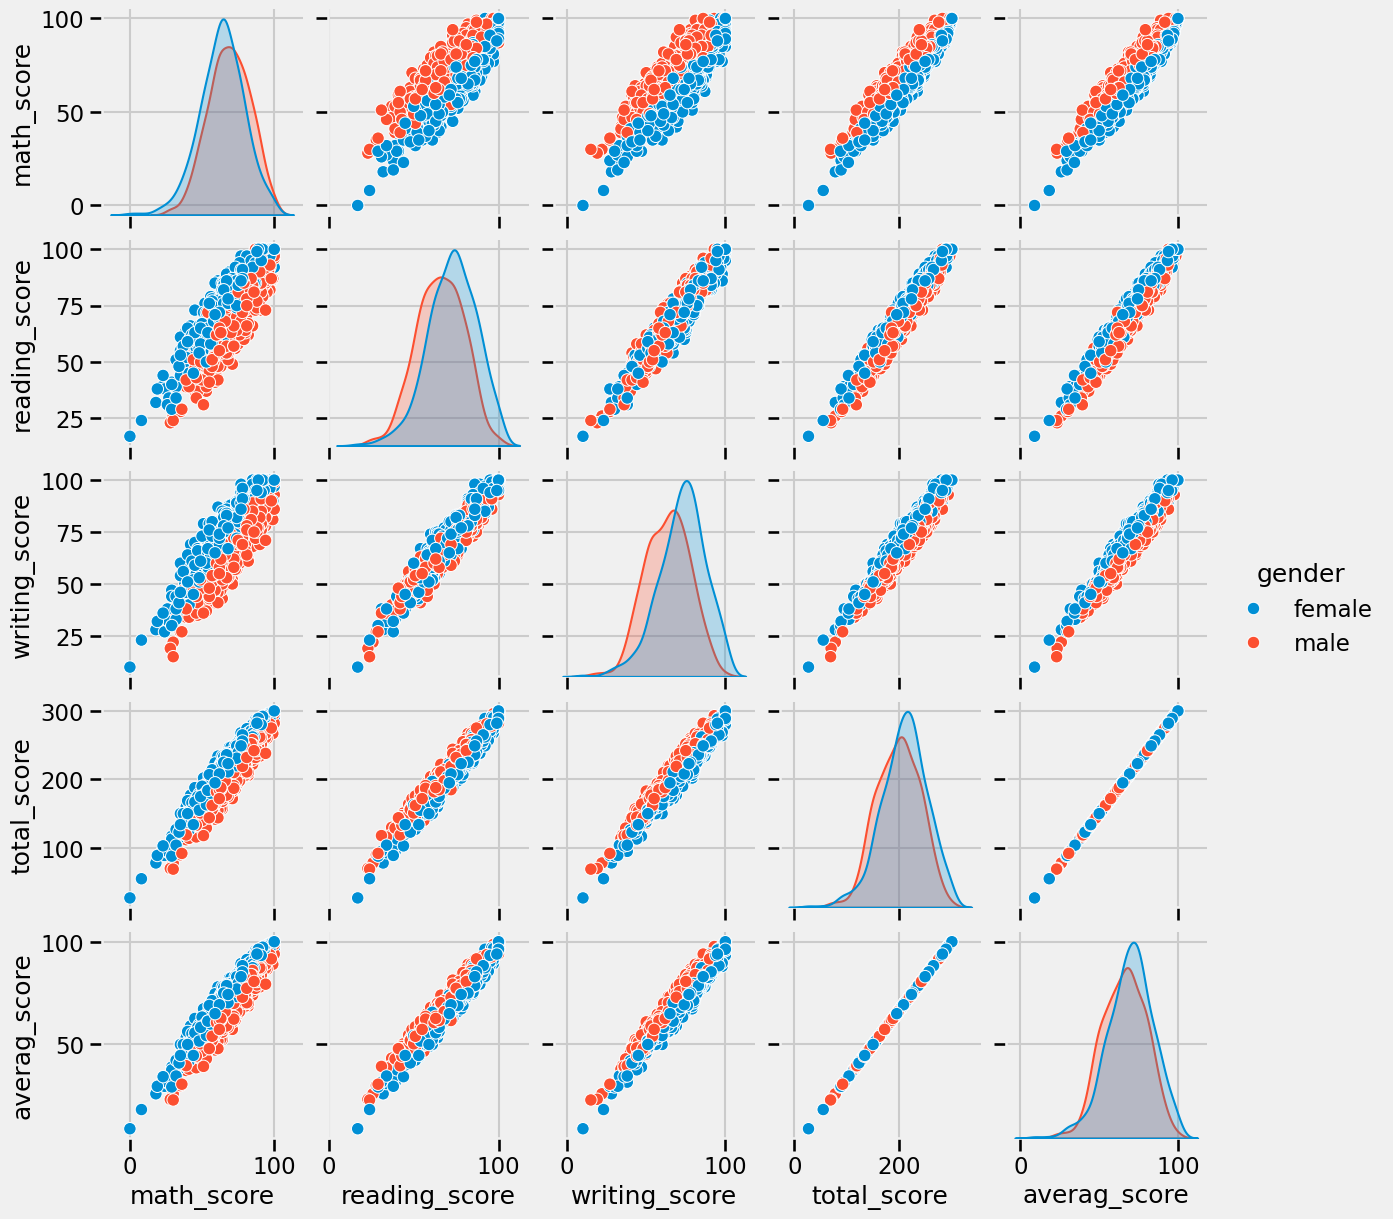

In [110]:
#Analysis using pairplot
sns.pairplot(df,hue = 'gender')
plt.show()

all score increase linearly with each other

## **closing remarks**
1. Student's Performance is related with lunch, race, parental level education
2. Females lead in pass percentage and also are top-scorers
3. Student's Performance is not much related with test preparation course
4. Finishing preparation course is benefitial.
